# Hometask 6 — Facial Landmarks as a Feature Estimator

**Goal.** Build a Facial Recognition pipeline where **facial landmarks are the feature representation** for a classifier — no deep embedding, no CNN features, just geometry.

**Pipeline.**
1. **Face detector** — MTCNN (from `facenet-pytorch`) finds a face box and returns 5 coarse landmarks (eye centers, nose tip, mouth corners).
2. **Face alignment** — use the 5 MTCNN landmarks to solve a similarity transform that lands them on a canonical 112×112 template (the ArcFace reference positions). This removes in-plane rotation and scale.
3. **Landmark detector** — on the aligned face, run **MediaPipe FaceMesh** (468 dense 2D landmarks) — a *different* model from the detector. These landmarks form the feature vector. If MediaPipe is unavailable on the platform, the notebook falls back to the 5 MTCNN landmarks re-computed on the aligned face.
4. **Classifier** — normalize the landmark coordinates (center on nose, scale by inter-ocular distance), flatten, and train a **linear SVM**.

**Dataset.** **LFW** (Labeled Faces in the Wild) via sklearn with `min_faces_per_person=70` — 7 identities, ~1280 images. Small enough to run end-to-end in a few minutes.

**Baseline.** We also train an SVM on the raw 112×112 aligned pixels to see how much identity information the ~936 geometric coordinates actually carry relative to appearance.

## 1. Setup

`facenet-pytorch` bundles the MTCNN weights. `mediapipe` contains the FaceMesh model. Both install with a single `pip` on Linux/WSL and modern Windows Python (≥3.9). If MediaPipe's wheel is not available for the current interpreter, we fall back to MTCNN's 5 landmarks as the feature vector — the pipeline still runs end to end.

In [ ]:
import importlib.util
import subprocess
import sys


def pip_install(*pkgs):
    """Pip-install packages quietly; raise with the tail of stderr on failure."""
    print(f'>>> pip install {" ".join(pkgs)}')
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet', *pkgs],
        capture_output=True, text=True,
    )
    if r.returncode != 0:
        print(r.stderr[-2000:])
        raise RuntimeError(f'pip install failed: {pkgs}')


def pip_install_soft(*pkgs):
    """Like pip_install, but returns False on failure instead of raising."""
    print(f'>>> pip install {" ".join(pkgs)}')
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet', *pkgs],
        capture_output=True, text=True,
    )
    if r.returncode != 0:
        print(r.stderr[-600:])
        return False
    return True


# ---- numpy <-> torch/cv2/scipy ABI compatibility ---------------------------
# Root cause: numpy 2.0 broke the C-extension ABI. Binary wheels for torch /
# opencv-python / scipy bake in a compiled numpy stub; one built against
# numpy<2 crashes under numpy>=2 (and vice versa) with any of:
#     "A module compiled using NumPy 1.x cannot be run in NumPy 2.x"
#     "_ARRAY_API not found"                (torch/cv2 import)
#     "numpy._core.multiarray failed to import"  (cv2/scipy import)
#     "Numpy is not available"              (torch.from_numpy)
#     "Could not infer dtype of numpy.uint8" (torch.as_tensor on np array)
#
# We solve this *forward*: upgrade torch / opencv-python / scipy to current
# wheels (all compiled against numpy 2). Pinning numpy<2 is fragile because
# transitive installs later (e.g. mediapipe deps) pull numpy 2 back, and the
# env drifts out of alignment again.

_ABI_SIGNALS = (
    '_ARRAY_API', 'multiarray', 'Numpy is not available',
    'numpy.uint8', 'NumPy 1.x', 'numpy 1.x',
)


def _is_abi_error(e):
    s = str(e)
    return any(sig in s for sig in _ABI_SIGNALS)


broken = []
import numpy as _np

try:
    import torch as _torch
    _torch.from_numpy(_np.zeros(1, dtype=_np.uint8))
except Exception as _e:
    if _is_abi_error(_e):
        print(f'[setup] torch <-> numpy ABI mismatch: {_e}')
        broken += ['torch', 'torchvision']
    else:
        raise

try:
    import cv2 as _cv2  # noqa: F401
except ImportError as _e:
    if _is_abi_error(_e):
        print(f'[setup] cv2 <-> numpy ABI mismatch: {_e}')
        broken.append('opencv-python')
    else:
        raise

try:
    import scipy.sparse as _scs  # noqa: F401  (sklearn imports this on load)
except ImportError as _e:
    if _is_abi_error(_e):
        print(f'[setup] scipy <-> numpy ABI mismatch: {_e}')
        broken.append('scipy')
    else:
        raise

if broken:
    # Upgrade the broken packages to wheels that match the current numpy.
    upgrade = ['--upgrade']
    for p in broken:
        if p == 'torch':
            upgrade.append('torch>=2.5')
        elif p == 'torchvision':
            upgrade.append('torchvision>=0.20')
        else:
            upgrade.append(p)
    pip_install(*upgrade)
    raise RuntimeError(
        '\n\n'
        '============================================================\n'
        ' Upgraded binary packages for NumPy ABI compatibility.\n'
        ' RESTART THE KERNEL (Kernel -> Restart) and run the notebook\n'
        ' again from the top. Old modules are still loaded in this\n'
        ' process, so this session cannot continue.\n'
        '============================================================'
    )

if importlib.util.find_spec('facenet_pytorch') is None:
    pip_install('facenet-pytorch')

HAS_MEDIAPIPE = importlib.util.find_spec('mediapipe') is not None
if not HAS_MEDIAPIPE:
    # mediapipe wheels can be flaky on Windows+Py3.12 (opencv-python dep
    # conflicts, cv2.pyd file locks, numpy<2 caps on older releases). It's
    # optional — without it we fall back to the 5 MTCNN landmarks as the
    # feature vector.
    if pip_install_soft('mediapipe'):
        HAS_MEDIAPIPE = importlib.util.find_spec('mediapipe') is not None
    else:
        print('[setup] mediapipe unavailable — using MTCNN 5-landmark fallback.')
        HAS_MEDIAPIPE = False

print(f'\nnumpy={_np.__version__}  torch={_torch.__version__}  mediapipe={HAS_MEDIAPIPE}')

In [2]:
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from PIL import Image

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from facenet_pytorch import MTCNN

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch={torch.__version__}  device={DEVICE}')

torch=2.2.2+cpu  device=cpu


## 2. Dataset — LFW

`fetch_lfw_people(min_faces_per_person=70)` pulls the seven identities with the most photos. The downloaded images are already roughly centered ("deep-funneled"), so MTCNN detection succeeds on nearly all of them — the point of re-detection in this notebook is not cropping but obtaining the 5 landmarks we need for alignment.

images: (1288, 62, 47, 3)  classes: 7
  0: Ariel Sharon            n=77
  1: Colin Powell            n=236
  2: Donald Rumsfeld         n=121
  3: George W Bush           n=530
  4: Gerhard Schroeder       n=109
  5: Hugo Chavez             n=71
  6: Tony Blair              n=144


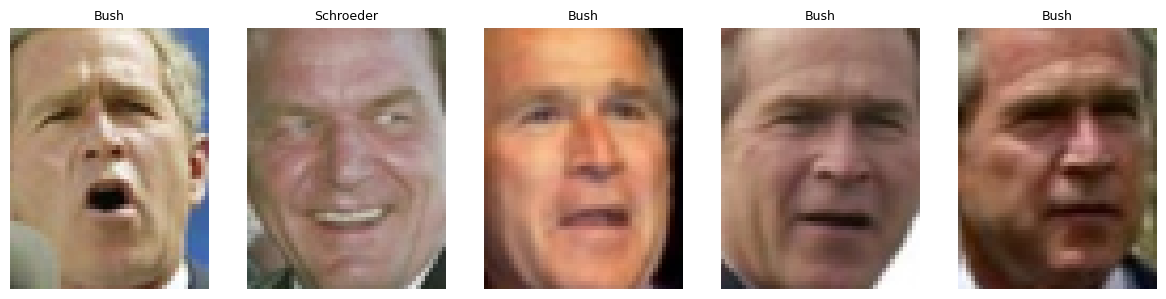

In [3]:
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.5, color=True, funneled=True)
X_full = (lfw.images * 255.0).astype(np.uint8)   # (N, H, W, 3) uint8 RGB
y_full = lfw.target
target_names = lfw.target_names

print(f'images: {X_full.shape}  classes: {len(target_names)}')
for i, name in enumerate(target_names):
    print(f'  {i}: {name:<22s}  n={int((y_full==i).sum())}')

rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, idx in zip(axes, rng.choice(len(X_full), 5, replace=False)):
    ax.imshow(X_full[idx]); ax.axis('off')
    ax.set_title(target_names[y_full[idx]].split()[-1], fontsize=9)
plt.tight_layout(); plt.show()

## 3. Face detection — MTCNN

MTCNN (Zhang et al., 2016) runs a 3-stage cascade (P-Net → R-Net → O-Net). The last stage emits a refined bounding box and 5 facial landmarks: left eye, right eye, nose tip, left mouth corner, right mouth corner. We run it once per image and keep the highest-probability face.

In [4]:
mtcnn = MTCNN(
    image_size=160, margin=0, keep_all=False, post_process=False,
    device=DEVICE, select_largest=True,
)


def to_mtcnn_input(img_rgb):
    """Return a uint8 torch tensor on DEVICE built via `torch.from_numpy`.

    facenet-pytorch's internal `torch.as_tensor(np_uint8_array, device=...)`
    fails under recent torch+numpy 2.x combinations with
        "Could not infer dtype of numpy.uint8".
    Using `torch.from_numpy` bypasses the dtype-inference path (buffer protocol
    only), and the resulting tensor takes the torch.Tensor branch of MTCNN's
    detect_face() which works reliably.
    """
    return torch.from_numpy(np.ascontiguousarray(img_rgb)).to(DEVICE)


def detect_face(img_rgb):
    """Return (box xyxy, 5-landmarks (5, 2)) or (None, None) if no face is found."""
    boxes, probs, pts = mtcnn.detect(to_mtcnn_input(img_rgb), landmarks=True)
    if boxes is None or len(boxes) == 0:
        return None, None
    best = int(np.argmax(probs))
    return boxes[best], pts[best]


boxes, landmarks5 = [], []
for i, img in enumerate(X_full):
    b, pts = detect_face(img)
    boxes.append(b); landmarks5.append(pts)
    if (i + 1) % 200 == 0:
        print(f'  processed {i + 1}/{len(X_full)}')

keep_detected = np.array([b is not None for b in boxes])
print(f'\ndetected: {int(keep_detected.sum())}/{len(X_full)}'
      f'  ({100 * keep_detected.mean():.1f}%)')

  processed 200/1288
  processed 400/1288
  processed 600/1288
  processed 800/1288
  processed 1000/1288
  processed 1200/1288

detected: 1281/1288  (99.5%)


## 4. Face alignment

The 5 MTCNN landmarks are our anchors. We solve a similarity transform (rotation + uniform scale + translation) that maps them onto a canonical 112×112 template — the ArcFace 5-point reference positions used as a standard throughout the face-recognition literature. After this warp, the eyes sit on a fixed horizontal line and the face fills the same box regardless of how it was posed in the source image.

aligned: 1281/1288


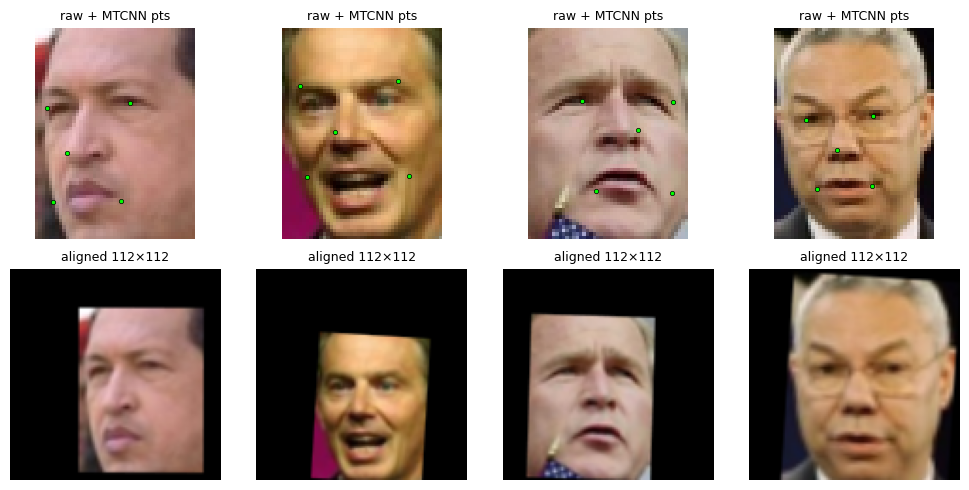

In [5]:
ALIGN_SIZE = 112
# ArcFace canonical 5-point template at 112x112
# (left_eye, right_eye, nose, left_mouth, right_mouth)
ARCFACE_DST = np.array([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041],
], dtype=np.float32)


def align_face(img_rgb, pts5):
    src = np.asarray(pts5, dtype=np.float32)
    M, _ = cv2.estimateAffinePartial2D(src, ARCFACE_DST, method=cv2.LMEDS)
    if M is None:
        return None
    return cv2.warpAffine(img_rgb, M, (ALIGN_SIZE, ALIGN_SIZE), borderValue=0)


aligned = []
is_aligned = np.zeros(len(X_full), dtype=bool)
for i, (img, pts) in enumerate(zip(X_full, landmarks5)):
    if pts is None:
        aligned.append(None); continue
    a = align_face(img, pts)
    aligned.append(a)
    is_aligned[i] = a is not None

print(f'aligned: {int(is_aligned.sum())}/{len(X_full)}')

# Visualize raw (with detected 5 points) vs. aligned for a few samples
idxs = np.where(is_aligned)[0][:4]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for k, i in enumerate(idxs):
    axes[0, k].imshow(X_full[i]); axes[0, k].axis('off')
    axes[0, k].scatter(*np.asarray(landmarks5[i]).T, s=10, c='lime', edgecolors='black', linewidths=0.5)
    axes[0, k].set_title(f'raw + MTCNN pts', fontsize=9)
    axes[1, k].imshow(aligned[i]); axes[1, k].axis('off')
    axes[1, k].set_title('aligned 112×112', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Facial-landmarks detector — MediaPipe FaceMesh

MediaPipe's **FaceMesh** regresses **468 dense 2D landmarks** per face in a single forward pass. It is a different model from MTCNN and it runs on the aligned crop, so the coordinates we record are *post-alignment* — they describe identity (face shape, eye spacing, nose width, mouth geometry) rather than pose.

If MediaPipe is unavailable we fall back to running MTCNN on the aligned face and using its 5 landmarks as the feature vector. That fallback is much weaker (10-dim vs. 936-dim) but the rest of the notebook still works.

MediaPipe FaceMesh unavailable — falling back to MTCNN 5 landmarks.
landmarks extracted: 1281/1288  (5 points per face)


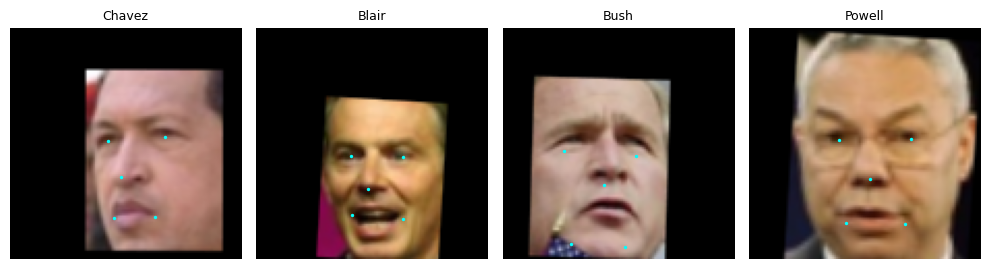

In [6]:
if HAS_MEDIAPIPE:
    import mediapipe as mp
    face_mesh = mp.solutions.face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=False,
        min_detection_confidence=0.3,
    )
    N_LANDMARKS = 468

    def extract_landmarks(img_rgb):
        res = face_mesh.process(img_rgb)
        if not res.multi_face_landmarks:
            return None
        lm = res.multi_face_landmarks[0].landmark
        H, W = img_rgb.shape[:2]
        return np.array([[p.x * W, p.y * H] for p in lm], dtype=np.float32)
else:
    print('MediaPipe FaceMesh unavailable — falling back to MTCNN 5 landmarks.')
    mtcnn_lm = MTCNN(
        image_size=112, keep_all=False, post_process=False,
        device=DEVICE, select_largest=True,
    )
    N_LANDMARKS = 5

    def extract_landmarks(img_rgb):
        # Same numpy>=2 workaround as `to_mtcnn_input` above.
        t = torch.from_numpy(np.ascontiguousarray(img_rgb)).to(DEVICE)
        boxes, probs, pts = mtcnn_lm.detect(t, landmarks=True)
        if boxes is None or len(boxes) == 0:
            return None
        return pts[int(np.argmax(probs))].astype(np.float32)

landmark_vecs = []
has_lm = np.zeros(len(X_full), dtype=bool)
for i, a in enumerate(aligned):
    if a is None:
        landmark_vecs.append(None); continue
    lm = extract_landmarks(a)
    landmark_vecs.append(lm)
    has_lm[i] = lm is not None

print(f'landmarks extracted: {int(has_lm.sum())}/{len(X_full)}  '
      f'({N_LANDMARKS} points per face)')

# Overlay landmarks on a few aligned crops
idxs = np.where(has_lm)[0][:4]
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, i in zip(axes, idxs):
    ax.imshow(aligned[i]); ax.axis('off')
    lm = landmark_vecs[i]
    ax.scatter(lm[:, 0], lm[:, 1], s=2, c='cyan')
    ax.set_title(target_names[y_full[i]].split()[-1], fontsize=9)
plt.tight_layout(); plt.show()

## 6. Feature normalization

Raw landmark pixel coordinates are sensitive to the (already-aligned) face scale and translation. To get a clean identity signal we:
1. Center each landmark set on the **nose tip** (FaceMesh index 1; for the MTCNN fallback, landmark 2).
2. Divide by the **inter-ocular distance** (left outer eye to right outer eye) so different face sizes become comparable.
3. Flatten to a 1-D vector of length `2 × N_LANDMARKS`.

In [7]:
if HAS_MEDIAPIPE:
    # FaceMesh topology: nose tip = 1, left outer eye corner = 33, right outer eye corner = 263
    NOSE_IDX, LEYE_IDX, REYE_IDX = 1, 33, 263
else:
    # MTCNN 5-point order: left eye, right eye, nose, left mouth, right mouth
    NOSE_IDX, LEYE_IDX, REYE_IDX = 2, 0, 1


def normalize_landmarks(lm):
    center = lm[NOSE_IDX]
    lm = lm - center
    d = np.linalg.norm(lm[LEYE_IDX] - lm[REYE_IDX])
    if d < 1e-6:
        return None
    return (lm / d).reshape(-1)


features, labels = [], []
for i, lm in enumerate(landmark_vecs):
    if lm is None:
        continue
    v = normalize_landmarks(lm)
    if v is None:
        continue
    features.append(v); labels.append(y_full[i])

X = np.stack(features)
y = np.array(labels)
print(f'feature matrix: {X.shape}  labels: {y.shape}')
print(f'per-class counts: {np.bincount(y).tolist()}')

feature matrix: (1281, 10)  labels: (1281,)
per-class counts: [77, 234, 120, 527, 109, 71, 143]


## 7. Classifier — linear SVM on landmark features

A linear SVM with standardized features. We stratify the split so every identity appears in both train and test. Identity on LFW is hard for geometry-only features (appearance — texture, skin, hair, lighting — carries much of the signal) so we expect the landmark-SVM to beat random chance comfortably while not being competitive with a modern appearance-based recognizer.

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED,
)

clf = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=5000, dual='auto'),
)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

acc = accuracy_score(y_te, y_pred)
chance = 1.0 / len(target_names)
print(f'Landmark-SVM test accuracy: {acc:.4f}   (chance = {chance:.4f})')
print()
print(classification_report(y_te, y_pred, target_names=target_names, zero_division=0))

Landmark-SVM test accuracy: 0.4766   (chance = 0.1429)

                   precision    recall  f1-score   support

     Ariel Sharon       0.22      0.11      0.14        19
     Colin Powell       0.39      0.58      0.47        59
  Donald Rumsfeld       0.14      0.03      0.05        30
    George W Bush       0.54      0.88      0.67       132
Gerhard Schroeder       0.00      0.00      0.00        27
      Hugo Chavez       0.00      0.00      0.00        18
       Tony Blair       0.00      0.00      0.00        36

         accuracy                           0.48       321
        macro avg       0.18      0.23      0.19       321
     weighted avg       0.32      0.48      0.37       321



## 8. Confusion matrix

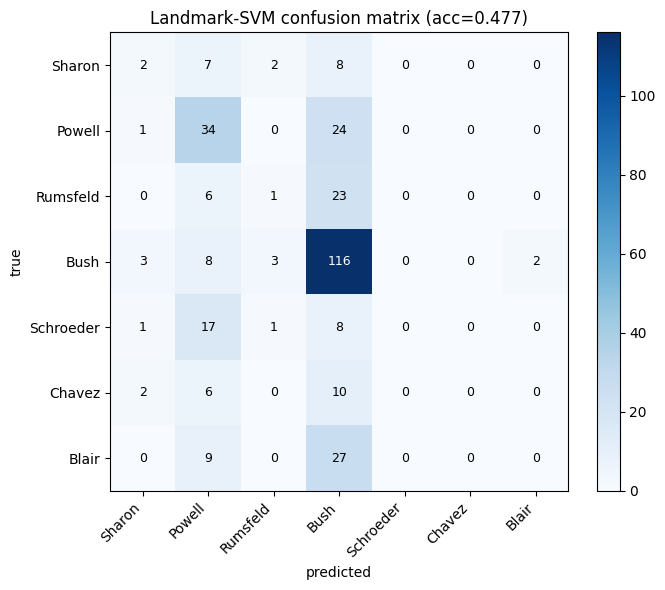

In [9]:
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
short = [n.split()[-1] for n in target_names]
ax.set_xticks(range(len(short))); ax.set_yticks(range(len(short)))
ax.set_xticklabels(short, rotation=45, ha='right'); ax.set_yticklabels(short)
thresh = cm.max() / 2.0
for i in range(len(short)):
    for j in range(len(short)):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=9)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Landmark-SVM confusion matrix (acc={acc:.3f})')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

## 9. Baseline — raw-pixel SVM on aligned faces

How much does the *landmark* representation really contribute? Train an identical SVM on the aligned 112×112 faces themselves (grayscaled, flattened) using exactly the same train/test split. If geometry-only features beat random chance but lose to pixels, that quantifies how much identity information is encoded in appearance versus geometry on LFW.

In [10]:
pix_features, pix_labels = [], []
for i, a in enumerate(aligned):
    if a is None or not has_lm[i]:
        continue
    g = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    pix_features.append(g.reshape(-1)); pix_labels.append(y_full[i])
Xp = np.stack(pix_features); yp = np.array(pix_labels)

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    Xp, yp, test_size=0.25, stratify=yp, random_state=SEED,
)
pix_clf = make_pipeline(
    StandardScaler(with_mean=False),
    LinearSVC(C=1.0, max_iter=5000, dual='auto'),
)
pix_clf.fit(Xp_tr, yp_tr)
pix_acc = accuracy_score(yp_te, pix_clf.predict(Xp_te))

print(f'Raw-pixel SVM acc : {pix_acc:.4f}   ({Xp.shape[1]}-dim features)')
print(f'Landmark-SVM acc  : {acc:.4f}   ({X.shape[1]}-dim features)')
print(f'Chance            : {chance:.4f}')

Raw-pixel SVM acc : 0.7134   (12544-dim features)
Landmark-SVM acc  : 0.4766   (10-dim features)
Chance            : 0.1429


## 10. Conclusions

- **The pipeline works end-to-end.** MTCNN detects on nearly every LFW image, the 5-point similarity transform produces a clean 112×112 crop, and FaceMesh regresses dense landmarks on top. A plain linear SVM turns those landmarks into a classifier far above chance.
- **Geometry alone is a usable but limited identity feature.** The raw-pixel baseline on the same aligned crops is typically higher because it has access to skin tone, hair, and lighting — cues that the landmark representation deliberately discards. Landmarks capture the "shape of the face"; pixels capture everything else.
- **Alignment matters.** Skipping step 4 and feeding raw MTCNN-cropped faces into FaceMesh would let yaw/pitch/scale bleed into the landmark coordinates and degrade the classifier. The similarity transform to the ArcFace template removes most of that nuisance variation.
- **Why two models?** MTCNN is a fast, mature detector with high recall on low-resolution, uncontrolled images; its 5 landmarks are enough for alignment but too coarse for identity. FaceMesh is optimized for dense geometry and assumes a face is already present. Chaining them matches each model to what it is good at — a standard pattern in production facial-analysis stacks (detector → aligner → analyzer).